In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [12]:
# import data

df_student = pd.read_csv("dataset/student_math_clean.csv")
df_student.head()


,student_id,school,sex,age,address_type,family_size,parent_status,mother_education,father_education,mother_job,...,family_relationship,free_time,social,weekday_alcohol,weekend_alcohol,health,absences,grade_1,grade_2,final_grade
0,1,GP,F,18,Urban,Greater than 3,Apart,higher education,higher education,at_home,...,4,3,4,1,1,3,6,5,6,6
1,2,GP,F,17,Urban,Greater than 3,Living together,primary education (4th grade),primary education (4th grade),at_home,...,5,3,3,1,1,3,4,5,5,6
2,3,GP,F,15,Urban,Less than or equal to 3,Living together,primary education (4th grade),primary education (4th grade),at_home,...,4,3,2,2,3,3,10,7,8,10
3,4,GP,F,15,Urban,Greater than 3,Living together,higher education,5th to 9th grade,health,...,3,2,2,1,1,5,2,15,14,15
4,5,GP,F,16,Urban,Greater than 3,Living together,secondary education,secondary education,other,...,4,3,2,1,2,5,4,6,10,10


In [7]:
df_student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   student_id             395 non-null    int64 
 1   school                 395 non-null    object
 2   sex                    395 non-null    object
 3   age                    395 non-null    int64 
 4   address_type           395 non-null    object
 5   family_size            395 non-null    object
 6   parent_status          395 non-null    object
 7   mother_education       395 non-null    object
 8   father_education       395 non-null    object
 9   mother_job             395 non-null    object
 10  father_job             395 non-null    object
 11  school_choice_reason   395 non-null    object
 12  guardian               395 non-null    object
 13  travel_time            395 non-null    object
 14  study_time             395 non-null    object
 15  class_failures         

In [8]:
df_student.columns

Index(['student_id', 'school', 'sex', 'age', 'address_type', 'family_size',
       'parent_status', 'mother_education', 'father_education', 'mother_job',
       'father_job', 'school_choice_reason', 'guardian', 'travel_time',
       'study_time', 'class_failures', 'school_support', 'family_support',
       'extra_paid_classes', 'activities', 'nursery_school', 'higher_ed',
       'internet_access', 'romantic_relationship', 'family_relationship',
       'free_time', 'social', 'weekday_alcohol', 'weekend_alcohol', 'health',
       'absences', 'grade_1', 'grade_2', 'final_grade'],
      dtype='object')

In [9]:
df_student2 = df_student.copy()

In [15]:
cols_toencode = ['student_id', 'school', 'sex', 'age', 'address_type', 'family_size',
       'parent_status', 'mother_education', 'father_education', 'mother_job',
       'father_job', 'school_choice_reason','guardian', 'travel_time',
       'study_time', 'school_support', 'family_support',
       'extra_paid_classes', 'activities', 'nursery_school', 'higher_ed',
       'internet_access', 'romantic_relationship']

for col in cols_toencode:

    # label encoding
    le = LabelEncoder()
    df_student2[col] = le.fit_transform(df_student2[col])
    print(f"Label Encoding {col}: {le.classes_}")

df_student2.head()

Label Encoding student_id: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239

,student_id,school,sex,age,address_type,family_size,parent_status,mother_education,father_education,mother_job,...,family_relationship,free_time,social,weekday_alcohol,weekend_alcohol,health,absences,grade_1,grade_2,final_grade
0,0,0,0,3,1,0,0,1,1,0,...,4,3,4,1,1,3,6,5,6,6
1,1,0,0,2,1,0,1,3,3,0,...,5,3,3,1,1,3,4,5,5,6
2,2,0,0,0,1,1,1,3,3,0,...,4,3,2,2,3,3,10,7,8,10
3,3,0,0,0,1,0,1,1,0,1,...,3,2,2,1,1,5,2,15,14,15
4,4,0,0,1,1,0,1,4,4,2,...,4,3,2,1,2,5,4,6,10,10


In [18]:
X = df_student2
X.head()


,student_id,school,sex,age,address_type,family_size,parent_status,mother_education,father_education,mother_job,...,family_relationship,free_time,social,weekday_alcohol,weekend_alcohol,health,absences,grade_1,grade_2,final_grade
0,0,0,0,3,1,0,0,1,1,0,...,4,3,4,1,1,3,6,5,6,6
1,1,0,0,2,1,0,1,3,3,0,...,5,3,3,1,1,3,4,5,5,6
2,2,0,0,0,1,1,1,3,3,0,...,4,3,2,2,3,3,10,7,8,10
3,3,0,0,0,1,0,1,1,0,1,...,3,2,2,1,1,5,2,15,14,15
4,4,0,0,1,1,0,1,4,4,2,...,4,3,2,1,2,5,4,6,10,10


In [19]:
# scaler
scaler = StandardScaler()
df_student_scaled = scaler.fit_transform(X)

In [20]:
# PCA
model_pca = PCA(random_state=42)
X_pca = model_pca.fit_transform(df_student_scaled)

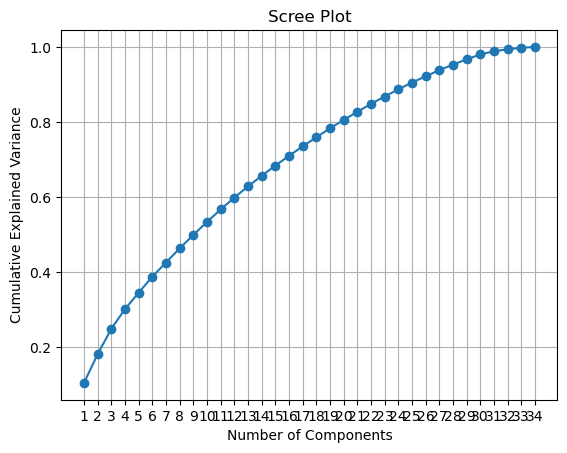

In [21]:
# pemilihan jumlah komponen PCA
# scree plot menggunakan explained variance
explained_variance = model_pca.explained_variance_ratio_
explained_variance_cumsum = np.cumsum(explained_variance)

plt.figure()
plt.plot(explained_variance_cumsum, marker='o')

plt.title('Scree Plot')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(ticks=np.arange(len(explained_variance_cumsum)), labels=np.arange(1, len(explained_variance_cumsum)+1))
plt.grid()
plt.show()

In [22]:
# ambil 24 komponen (70% variance explained)
model_pca_24 = PCA(n_components=24, random_state=42)
X_pca_24 = model_pca_24.fit_transform(df_student_scaled)

In [23]:
X_pca_24.shape

(395, 24)

In [24]:
# clustering dengan DBSCAN
# DBSCAN tidak perlu menentukan jumlah cluster di awal

model_dbscan = DBSCAN(eps=1, min_samples=24)

# buat kolom cluster
df_student2['cluster'] = model_dbscan.fit_predict(X_pca_24)

In [25]:
df_student2.head()

,student_id,school,sex,age,address_type,family_size,parent_status,mother_education,father_education,mother_job,...,free_time,social,weekday_alcohol,weekend_alcohol,health,absences,grade_1,grade_2,final_grade,cluster
0,0,0,0,3,1,0,0,1,1,0,...,3,4,1,1,3,6,5,6,6,-1
1,1,0,0,2,1,0,1,3,3,0,...,3,3,1,1,3,4,5,5,6,-1
2,2,0,0,0,1,1,1,3,3,0,...,3,2,2,3,3,10,7,8,10,-1
3,3,0,0,0,1,0,1,1,0,1,...,2,2,1,1,5,2,15,14,15,-1
4,4,0,0,1,1,0,1,4,4,2,...,3,2,1,2,5,4,6,10,10,-1


In [26]:
df_student2['cluster'].value_counts()

cluster
-1    395
Name: count, dtype: int64

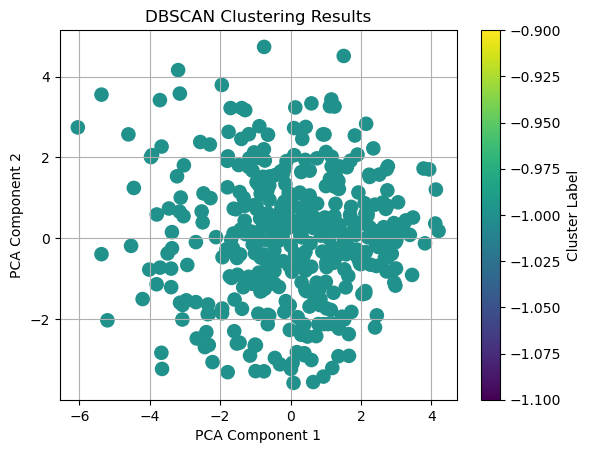

In [28]:
# optional - visualisasi hasil clustering
plt.figure()
plt.scatter(X_pca_24[:, 0], X_pca_24[:, 1], c=df_student2['cluster'], cmap='viridis', s=90)
plt.title('DBSCAN Clustering Results')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')
plt.grid()
plt.show()